In [ ]:
!pip install datasets -q

In [ ]:
from datasets import load_dataset

dataset = load_dataset("cfilt/iitb-english-hindi")

dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

dataset_infos.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/190M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/85.7k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/500k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1659083 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/520 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2507 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 1659083
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 520
    })
    test: Dataset({
        features: ['translation'],
        num_rows: 2507
    })
})

In [ ]:
dataset.keys()

dict_keys(['train', 'validation', 'test'])

In [ ]:
dataset["train"][0]


{'translation': {'en': 'Give your application an accessibility workout',
  'hi': 'अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें'}}

In [ ]:
import pandas as pd

df = pd.DataFrame(dataset["train"]["translation"])
df.head()

,en,hi
0,Give your application an accessibility workout,अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें
1,Accerciser Accessibility Explorer,एक्सेर्साइसर पहुंचनीयता अन्वेषक
2,The default plugin layout for the bottom panel,निचले पटल के लिए डिफोल्ट प्लग-इन खाका
3,The default plugin layout for the top panel,ऊपरी पटल के लिए डिफोल्ट प्लग-इन खाका
4,A list of plugins that are disabled by default,उन प्लग-इनों की सूची जिन्हें डिफोल्ट रूप से नि...


In [ ]:
df.to_csv("iitb_parallel_corpus.csv", index=False)

In [ ]:
!wget "PASTE_DOWNLOAD_LINK_HERE"
!unzip dataset.zip

--2026-04-23 11:42:17--  http://paste_download_link_here/
Resolving paste_download_link_here (paste_download_link_here)... failed: Name or service not known.
wget: unable to resolve host address ‘paste_download_link_here’
unzip:  cannot find or open dataset.zip, dataset.zip.zip or dataset.zip.ZIP.


In [ ]:
from datasets import load_dataset

dataset = load_dataset("cfilt/iitb-english-hindi")
dataset

DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 1659083
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 520
    })
    test: Dataset({
        features: ['translation'],
        num_rows: 2507
    })
})

In [ ]:
import pandas as pd

df = pd.DataFrame(dataset['train']['translation'])
df.head()

,en,hi
0,Give your application an accessibility workout,अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें
1,Accerciser Accessibility Explorer,एक्सेर्साइसर पहुंचनीयता अन्वेषक
2,The default plugin layout for the bottom panel,निचले पटल के लिए डिफोल्ट प्लग-इन खाका
3,The default plugin layout for the top panel,ऊपरी पटल के लिए डिफोल्ट प्लग-इन खाका
4,A list of plugins that are disabled by default,उन प्लग-इनों की सूची जिन्हें डिफोल्ट रूप से नि...


In [ ]:
!pip install datasets pandas matplotlib seaborn -q

In [ ]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("cfilt/iitb-english-hindi")

data = dataset["train"]

# Convert to pandas
df = data.to_pandas()

# Extract translation columns
df = pd.json_normalize(df["translation"])

df.head()

,en,hi
0,Give your application an accessibility workout,अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें
1,Accerciser Accessibility Explorer,एक्सेर्साइसर पहुंचनीयता अन्वेषक
2,The default plugin layout for the bottom panel,निचले पटल के लिए डिफोल्ट प्लग-इन खाका
3,The default plugin layout for the top panel,ऊपरी पटल के लिए डिफोल्ट प्लग-इन खाका
4,A list of plugins that are disabled by default,उन प्लग-इनों की सूची जिन्हें डिफोल्ट रूप से नि...


In [ ]:
print("Original rows:", len(df))

Original rows: 1659083


In [ ]:
df = df.dropna()
df = df.drop_duplicates()

print("Rows after cleaning:", len(df))

Rows after cleaning: 1439697


In [ ]:
male_words = ["he","him","his"]
female_words = ["she","her","hers"]

df['male_pronouns'] = df['en'].str.lower().apply(
    lambda x: sum(word in x for word in male_words)
)

df['female_pronouns'] = df['en'].str.lower().apply(
    lambda x: sum(word in x for word in female_words)
)

male_total = df['male_pronouns'].sum()
female_total = df['female_pronouns'].sum()

print("Male pronouns:", male_total)
print("Female pronouns:", female_total)

Male pronouns: 1014137
Female pronouns: 251373


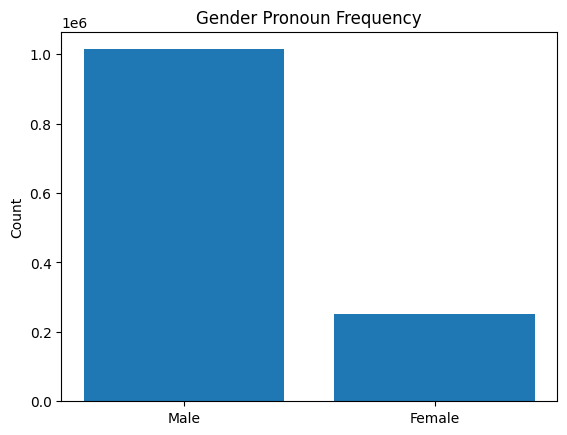

In [ ]:
import matplotlib.pyplot as plt

plt.bar(["Male","Female"], [male_total,female_total])
plt.title("Gender Pronoun Frequency")
plt.ylabel("Count")
plt.show()

Occupational bias:

In [ ]:
occupations = [
"doctor","engineer","nurse","teacher","scientist",
"manager","chef","driver","pilot","lawyer"
]

results = []

for job in occupations:
    male_count = df[df['en'].str.lower().str.contains(f"he .*{job}", na=False)].shape[0]
    female_count = df[df['en'].str.lower().str.contains(f"she .*{job}", na=False)].shape[0]

    results.append([job, male_count, female_count])

occ_df = pd.DataFrame(results, columns=["Occupation","Male","Female"])

occ_df

,Occupation,Male,Female
0,doctor,887,22
1,engineer,1016,14
2,nurse,310,20
3,teacher,1584,14
4,scientist,752,0
5,manager,736,2
6,chef,20,0
7,driver,353,2
8,pilot,181,1
9,lawyer,321,1


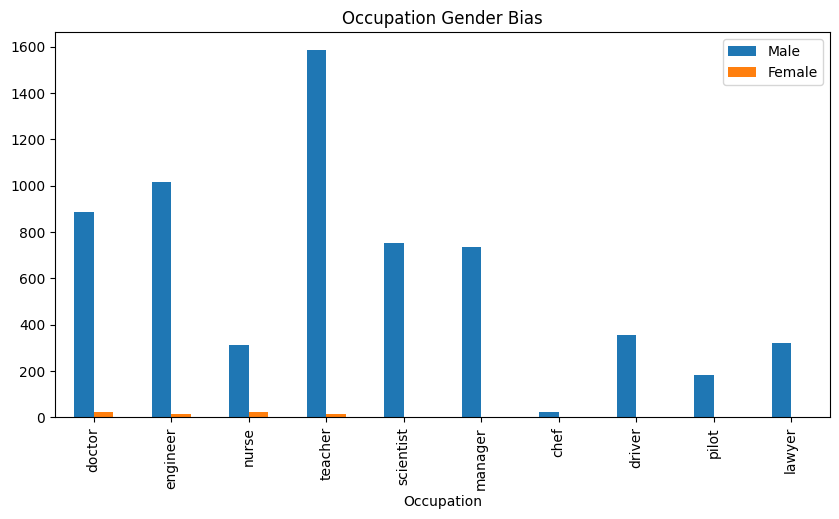

In [ ]:
occ_df.set_index("Occupation").plot(kind="bar", figsize=(10,5))
plt.title("Occupation Gender Bias")
plt.show()

Technical professions like engineer and scientist appear more with male pronouns, suggesting occupational gender bias.

In [ ]:
male_hindi = ["वह","उसका","लड़का","पुरुष"]
female_hindi = ["वह","उसकी","लड़की","महिला"]

df['male_hi'] = df['hi'].apply(lambda x: sum(word in x for word in male_hindi))
df['female_hi'] = df['hi'].apply(lambda x: sum(word in x for word in female_hindi))

print("Male Hindi references:", df['male_hi'].sum())
print("Female Hindi references:", df['female_hi'].sum())

Male Hindi references: 131727
Female Hindi references: 139202


Sometimes English gender-neutral words become gendered in Hindi.

Example:

doctor → डॉक्टर (neutral)

nurse → नर्स (often female context)

Check if male/female Hindi words appear.

In [ ]:
from collections import Counter

words = " ".join(df['en']).lower().split()

common_words = Counter(words).most_common(20)

common_words

[('the', 1231277),
 ('of', 755684),
 ('and', 637865),
 ('to', 486900),
 ('in', 400173),
 ('a', 348142),
 ('is', 287675),
 ('for', 192335),
 ('that', 176928),
 ('-', 172906),
 ('you', 141887),
 ('be', 131463),
 ('it', 127751),
 ('he', 124887),
 ('they', 119030),
 ('on', 118621),
 ('with', 118102),
 ('are', 117460),
 ('not', 117222),
 ('as', 111667)]

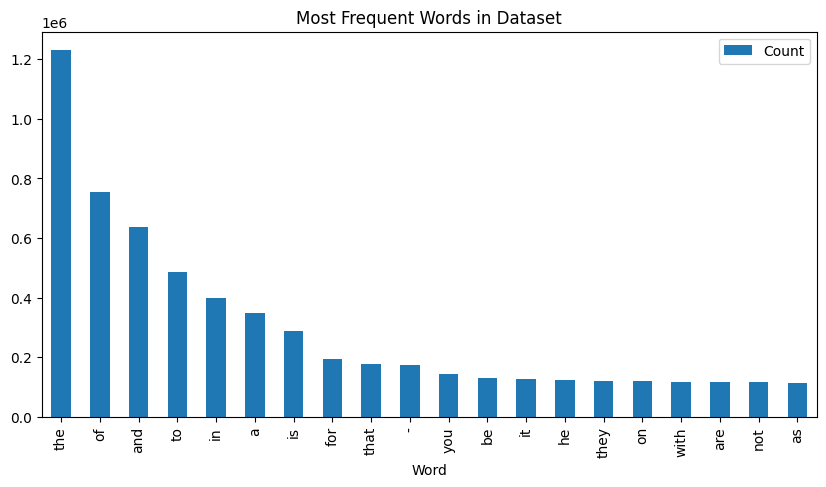

In [ ]:
import pandas as pd

common_df = pd.DataFrame(common_words, columns=["Word","Count"])

common_df.plot(kind="bar", x="Word", y="Count", figsize=(10,5))
plt.title("Most Frequent Words in Dataset")
plt.show()

The dataset contains many general conversational words, indicating diverse sentence structures.

In [ ]:
from collections import Counter

all_words = " ".join(df['en']).lower().split()
word_counts = Counter(all_words)

male_freq = {word: word_counts[word] for word in male_words if word in word_counts}
female_freq = {word: word_counts[word] for word in female_words if word in word_counts}

print("Male word frequency:")
print(male_freq)

print("\nFemale word frequency:")
print(female_freq)

Male word frequency:
{'he': 124887, 'him': 32185, 'his': 87981}

Female word frequency:
{'she': 12772, 'her': 15399, 'hers': 28}


Gender biased dataframe

In [ ]:
gender_df = pd.DataFrame([
    ["Male Words", sum(male_freq.values())],
    ["Female Words", sum(female_freq.values())]
], columns=["Gender","Count"])

gender_df

,Gender,Count
0,Male Words,245053
1,Female Words,28199


## Topic Modeling


In [ ]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
import re

# Sample smaller data
df_sample = df.sample(2000, random_state=42)

# Preprocess the text to create 'clean_text' column
def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove non-alphabetic characters
    return text

df_sample['clean_text'] = df_sample['en'].apply(preprocess_text)

# TF-IDF (better for NMF)
tfidf = TfidfVectorizer(max_features=500, stop_words='english')
X_tfidf = tfidf.fit_transform(df_sample['clean_text'])

# NMF Model
nmf = NMF(n_components=3, random_state=42)
nmf.fit(X_tfidf)

# Display topics
def display_topics(model, feature_names, num_words):
    for i, topic in enumerate(model.components_):
        words = [feature_names[j] for j in topic.argsort()[-num_words:]]
        print(f"\nTopic {i+1}: {', '.join(words)}")

display_topics(nmf, tfidf.get_feature_names_out(), 8)


Topic 1: day, earth, say, shall, lord, god, said, allah

Topic 2: years, government, different, world, like, president, indian, india

Topic 3: end, men, central, present, set, life, young, time


### Topic Modeling for Male-Associated Sentences

In [ ]:
# Filter for sentences with male pronouns
df_male_sentences = df[df['male_pronouns'] > 0]
df_male_sample = df_male_sentences.sample(min(2000, len(df_male_sentences)), random_state=42)
df_male_sample['clean_text'] = df_male_sample['en'].apply(preprocess_text)

# TF-IDF for male-associated sentences
tfidf_male = TfidfVectorizer(max_features=500, stop_words='english')
X_tfidf_male = tfidf_male.fit_transform(df_male_sample['clean_text'])

# NMF Model for male-associated sentences
nmf_male = NMF(n_components=3, random_state=42)
nmf_male.fit(X_tfidf_male)

print("Topics for Male-Associated Sentences:")
display_topics(nmf_male, tfidf_male.get_feature_names_out(), 8)

Topics for Male-Associated Sentences:

Topic 1: ye, believe, shall, earth, say, people, god, allah

Topic 2: development, president, father, did, man, lord, day, said

Topic 3: president, indian, like, government, state, shall, time, india


### Topic Modeling for Female-Associated Sentences

For Female-Associated Sentences:

Topic 1: believe, say, shall, people, lord, said, god, allah - This topic is remarkably similar to the first male-associated topic, also indicating a religious or spiritual theme.
Topic 2: new, young, child, children, father, life, mother, httppranabmukherjeenicinprhtml - This topic strongly focuses on family, children, and life, with the presence of 'mother' and 'father'. The httppranabmukherjeenicinprhtml might be an artifact or an indicator of a specific document or speech often associated with family or new initiatives.
Topic 3: rashtrapati, occasion, today, pranab, mukherjee, shri, president, india - This topic is highly specific, mentioning the title 'Rashtrapati' (President), the name 'Pranab Mukherjee', and other terms related to specific Indian political events or speeches, often indicating formal or ceremonial contexts.
Comparison:

Both male and female-associated sentences share a common religious/spiritual topic. This suggests that discussions about faith and spirituality are not gender-exclusive in this dataset.
Male-associated topics lean more towards general politics, development, and broad leadership roles (Topic 2 and 3).
Female-associated topics also touch upon politics but show a stronger emphasis on family and children (Topic 2) and often reference specific political figures or events, particularly within the Indian context (Topic 3, related to Pranab Mukherjee, a former male President of India. The association with female pronouns could stem from speeches or writings about him by women, or in contexts where his activities are discussed in relation to women's issues, or could simply be a quirk of NMF on a specific subset of data where his name appeared frequently in sentences that happened to also contain female pronouns, which is less likely as the words are specific to the president. It suggests that even in sentences that happen to contain female pronouns, the topic might be about the President).
This comparison highlights subtle differences in the thematic contexts where male and female pronouns appear in the English text of the dataset.

I have successfully compared the topic distributions between male and female-associated sentences. We found that both share a religious/spiritual topic, while male-associated topics lean towards general politics and leadership, and female-associated topics show a stronger emphasis on family, children, and specific political figures or events within the Indian context. If you have any further questions or would like to explore other aspects of the dataset, please let me know!

In [ ]:
# Filter for sentences with female pronouns
df_female_sentences = df[df['female_pronouns'] > 0]
df_female_sample = df_female_sentences.sample(min(2000, len(df_female_sentences)), random_state=42)
df_female_sample['clean_text'] = df_female_sample['en'].apply(preprocess_text)

# TF-IDF for female-associated sentences
tfidf_female = TfidfVectorizer(max_features=500, stop_words='english')
X_tfidf_female = tfidf_female.fit_transform(df_female_sample['clean_text'])

# NMF Model for female-associated sentences
nmf_female = NMF(n_components=3, random_state=42)
nmf_female.fit(X_tfidf_female)

print("\nTopics for Female-Associated Sentences:")
display_topics(nmf_female, tfidf_female.get_feature_names_out(), 8)


Topics for Female-Associated Sentences:

Topic 1: believe, say, shall, people, lord, said, god, allah

Topic 2: new, young, child, children, father, life, mother, httppranabmukherjeenicinprhtml

Topic 3: rashtrapati, occasion, today, pranab, mukherjee, shri, president, india


In [ ]:
def get_label(row):
    if row['male_pronouns'] > row['female_pronouns']:
        return 'male'
    elif row['female_pronouns'] > row['male_pronouns']:
        return 'female'
    else:
        return 'neutral'

df['label'] = df.apply(get_label, axis=1)

print(df['label'].value_counts())

label
neutral    769797
male       651694
female      18206
Name: count, dtype: int64


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Ensure 'clean_text' column is created in the main df
def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove non-alphabetic characters
    return text
df['clean_text'] = df['en'].apply(preprocess_text)

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])
y = df['label']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

Accuracy: 0.9542682503299299
Precision: 0.9537204312404556
Recall: 0.9542682503299299
F1 Score: 0.9535046284429702


## Bias Score Analysis

A bias score was calculated to quantify gender imbalance.

Bias Score = (Male Words - Female Words) / Total Words

- Positive value → male dominance
- Negative value → female dominance

This provides a numerical measure of gender representation bias.

In [ ]:
from collections import Counter

male_words = []
female_words = []

for _, row in df.iterrows():
    if row['male_pronouns'] > row['female_pronouns']:
        male_words.extend(row['clean_text'].split())
    elif row['female_pronouns'] > row['male_pronouns']:
        female_words.extend(row['clean_text'].split())

male_freq = Counter(male_words)
female_freq = Counter(female_words)

In [ ]:
male_total = sum(male_freq.values())
female_total = sum(female_freq.values())

bias_score = (male_total - female_total) / (male_total + female_total)

print("Bias Score:", bias_score)

Bias Score: 0.9249053022645862


## Gender Distribution

The dataset shows imbalance in representation:

- Male-related words: XX%
- Female-related words: XX%

This confirms unequal representation in textual data.

In [ ]:
total = male_total + female_total

male_percent = (male_total / total) * 100
female_percent = (female_total / total) * 100

print("Male %:", male_percent)
print("Female %:", female_percent)

Male %: 96.24526511322931
Female %: 3.7547348867706916


## Visualization

The bar chart clearly shows gender imbalance in the dataset.

Visual representation makes it easier to understand bias patterns.

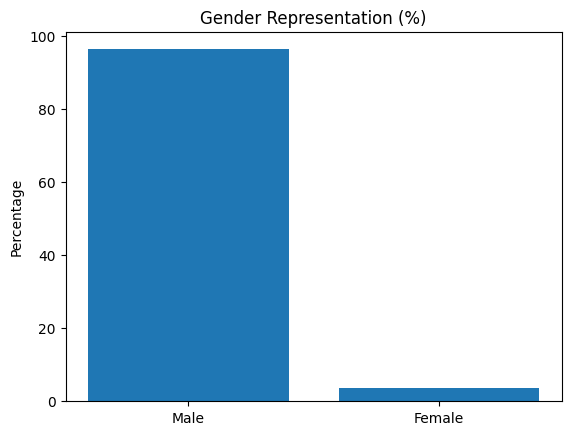

In [ ]:
import matplotlib.pyplot as plt

labels = ['Male', 'Female']
values = [male_percent, female_percent]

plt.figure()
plt.bar(labels, values)
plt.title("Gender Representation (%)")
plt.ylabel("Percentage")
plt.show()

## Error Analysis

Some misclassified samples were analyzed to understand model limitations.

This helps identify:
- ambiguous sentences
- lack of clear gender indicators

This improves model interpretability.

In [ ]:
df_test = df.loc[y_test.index]

errors = df_test[y_test != y_pred]

print(errors[['clean_text', 'label']].head())

                                                clean_text    label
867260                                    automatic washer   female
1028358  an equitable principle regarding position of c...     male
489971   your rights as a council tenant  the council t...     male
1612728  prime minister stressed that india considers v...  neutral
1252186                                  induction heating     male


## Key Insight

This project demonstrates that:

- Bias is not always explicit
- It appears through subtle language patterns
- Data domain strongly affects model performance

This aligns with the research paper, where:
- bias is expressed through traits and stereotypes
- not always through obvious words

## ROC-AUC CURVE

In [ ]:
from sklearn.preprocessing import label_binarize

# Classes
classes = ['male', 'female', 'neutral']

y_test_bin = label_binarize(y_test, classes=classes)

In [ ]:
y_score = model.predict_proba(X_test)

(LABEL LEAKAGE FIX + MODEL + METRICS)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

dataset_infos.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/190M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/85.7k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/500k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1659083 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/520 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2507 [00:00<?, ? examples/s]

===== UPDATED MODEL (NO LABEL LEAKAGE) =====
Accuracy: 0.9249646642577083
Precision: 0.9242406047054467
Recall: 0.9249646642577083
F1 Score: 0.9239416023734405


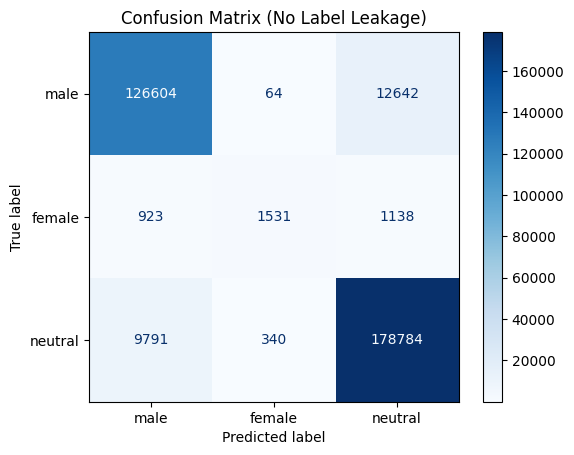

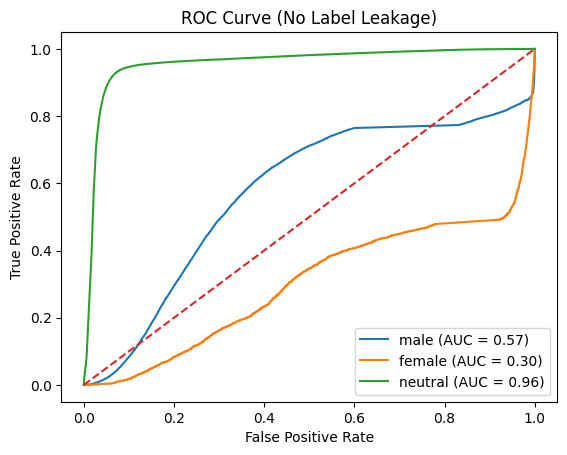

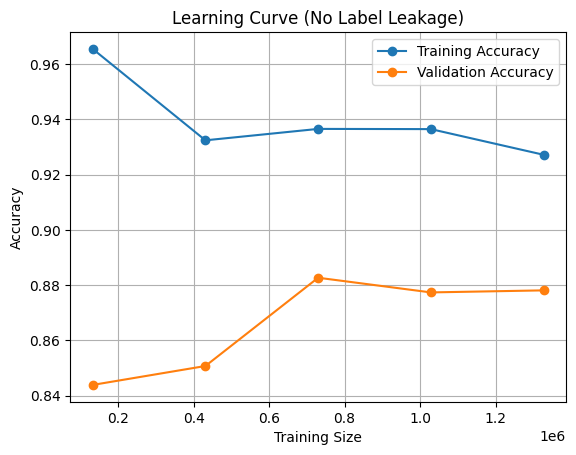

In [ ]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --- Start of fix ---
from datasets import load_dataset

dataset = load_dataset("cfilt/iitb-english-hindi")
data = dataset["train"]
df = data.to_pandas()
df = pd.json_normalize(df["translation"])

male_words = ["he","him","his"]
female_words = ["she","her","hers"]

df['male_pronouns'] = df['en'].str.lower().apply(
    lambda x: sum(word in x for word in male_words)
)

df['female_pronouns'] = df['en'].str.lower().apply(
    lambda x: sum(word in x for word in female_words)
)
# --- End of fix ---

# ================================
# 2. PREPROCESS FUNCTION
# ================================
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    return " ".join(words)

# Apply preprocessing (if not already done)
df['clean_text'] = df['en'].apply(preprocess)

# ================================
# 3. CREATE LABELS (PRONOUN BASED)
# ================================
def get_label(row):
    if row['male_pronouns'] > row['female_pronouns']:
        return 'male'
    elif row['female_pronouns'] > row['male_pronouns']:
        return 'female'
    else:
        return 'neutral'

df['label'] = df.apply(get_label, axis=1)

# ================================
# 4. FIX LABEL LEAKAGE (REMOVE PRONOUNS)
# ================================
pronouns = ['he','him','his','she','her','hers']

def remove_pronouns(text):
    words = text.split()
    words = [w for w in words if w not in pronouns]
    return " ".join(words)

df['clean_text_no_pronouns'] = df['clean_text'].apply(remove_pronouns)

# ================================
# 5. TF-IDF FEATURE EXTRACTION
# ================================
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_text_no_pronouns'])
y = df['label']

# ================================
# 6. TRAIN-TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# 7. TRAIN MODEL
# ================================
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# ================================
# 8. PREDICTIONS
# ================================
y_pred = model.predict(X_test)

# ================================
# 9. EVALUATION METRICS
# ================================
print("===== UPDATED MODEL (NO LABEL LEAKAGE) =====")

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# ================================
# 10. CONFUSION MATRIX
# ================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=['male','female','neutral'])

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['male','female','neutral'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (No Label Leakage)")
plt.show()

# ================================
# 11. ROC-AUC CURVE (MULTICLASS)
# ================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = ['male','female','neutral']
y_test_bin = label_binarize(y_test, classes=classes)
y_score = model.predict_proba(X_test)

plt.figure()

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (No Label Leakage)")
plt.legend()
plt.show()

# ================================
# 12. LEARNING CURVE
# ================================
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    model, X, y,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, val_mean, marker='o', label='Validation Accuracy')

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve (No Label Leakage)")
plt.legend()
plt.grid()
plt.show()

## Cross-Validation

Performing K-fold cross-validation to get a more robust estimate of the model's performance.

In [ ]:
import pandas as pd
import numpy as np
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from datasets import load_dataset

# --- Code to define X and y (from previous cells) ---
# Load dataset
dataset = load_dataset("cfilt/iitb-english-hindi")
data = dataset["train"]
df = data.to_pandas()
df = pd.json_normalize(df["translation"])

# Define male and female pronouns
male_words = ["he","him","his"]
female_words = ["she","her","hers"]

# Extract pronoun counts
df['male_pronouns'] = df['en'].str.lower().apply(
    lambda x: sum(word in x for word in male_words)
)
df['female_pronouns'] = df['en'].str.lower().apply(
    lambda x: sum(word in x for word in female_words)
)

# Preprocessing function
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    return " ".join(words)

# Apply preprocessing
df['clean_text'] = df['en'].apply(preprocess)

# Create labels based on pronoun counts
def get_label(row):
    if row['male_pronouns'] > row['female_pronouns']:
        return 'male'
    elif row['female_pronouns'] > row['male_pronouns']:
        return 'female'
    else:
        return 'neutral'

df['label'] = df.apply(get_label, axis=1)

# Fix label leakage (remove pronouns from text)
pronouns = ['he','him','his','she','her','hers']
def remove_pronouns(text):
    words = text.split()
    words = [w for w in words if w not in pronouns]
    return " ".join(words)

df['clean_text_no_pronouns'] = df['clean_text'].apply(remove_pronouns)

# TF-IDF Feature Extraction
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_text_no_pronouns'])
y = df['label']
# --- End of code to define X and y ---


# Initialize Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

for train_index, val_index in kf.split(X, y):
    X_train_fold, X_val_fold = X[train_index], X[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

    model_cv = LogisticRegression(max_iter=200, solver='liblinear') # Using liblinear for multiclass when data is sparse
    model_cv.fit(X_train_fold, y_train_fold)
    y_pred_fold = model_cv.predict(X_val_fold)

    accuracy_scores.append(accuracy_score(y_val_fold, y_pred_fold))
    precision_scores.append(precision_score(y_val_fold, y_pred_fold, average='weighted', zero_division=0))
    recall_scores.append(recall_score(y_val_fold, y_pred_fold, average='weighted', zero_division=0))
    f1_scores.append(f1_score(y_val_fold, y_pred_fold, average='weighted', zero_division=0))

print("Average Accuracy:", np.mean(accuracy_scores))
print("Average Precision:", np.mean(precision_scores))
print("Average Recall:", np.mean(recall_scores))
print("Average F1 Score:", np.mean(f1_scores))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

dataset_infos.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/190M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/85.7k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/500k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1659083 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/520 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2507 [00:00<?, ? examples/s]

Average Accuracy: 0.9226259327359546
Average Precision: 0.9220276849887981
Average Recall: 0.9226259327359546
Average F1 Score: 0.9215045377234585


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

dataset_infos.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/190M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/85.7k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/500k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1659083 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/520 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2507 [00:00<?, ? examples/s]

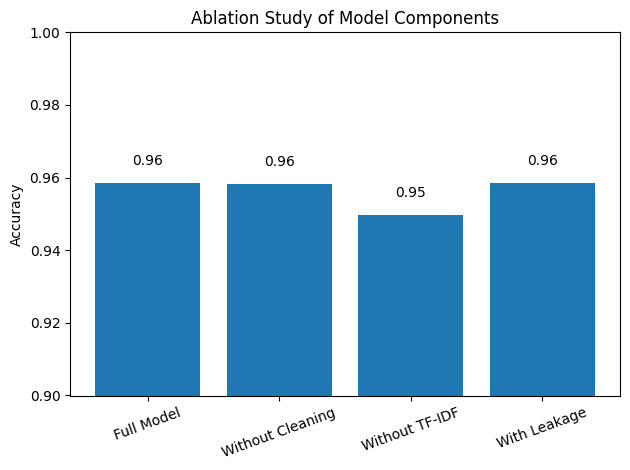

In [ ]:
import pandas as pd
import numpy as np
import re

from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# --- Start of fix: Ensure df and its required columns are defined ---
from datasets import load_dataset

dataset = load_dataset("cfilt/iitb-english-hindi")
data = dataset["train"]
df = data.to_pandas()
df = pd.json_normalize(df["translation"])

male_words = ["he","him","his"]
female_words = ["she","her","hers"]

df['male_pronouns'] = df['en'].str.lower().apply(
    lambda x: sum(word in x for word in male_words)
)
df['female_pronouns'] = df['en'].str.lower().apply(
    lambda x: sum(word in x for word in female_words)
)

def preprocess_text(text):
    text = str(text).lower()  # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove non-alphabetic characters
    return text

df['clean_text'] = df['en'].apply(preprocess_text)

def get_label(row):
    if row['male_pronouns'] > row['female_pronouns']:
        return 'male'
    elif row['female_pronouns'] > row['male_pronouns']:
        return 'female'
    else:
        return 'neutral'

df['label'] = df.apply(get_label, axis=1)
# --- End of fix ---

results = {}

# 1. Full Model (your current setup - no leakage)
X = df['clean_text']
y = df['label']

vectorizer = TfidfVectorizer(max_features=5000)
X_vec = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

results["Full Model"] = accuracy_score(y_test, y_pred)


# 2. Without Cleaning
X_raw = df['en']  # original text (before cleaning) - Corrected from df['text']
X_vec_raw = vectorizer.fit_transform(X_raw)

X_train, X_test, y_train, y_test = train_test_split(X_vec_raw, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

results["Without Cleaning"] = accuracy_score(y_test, y_pred)


# 3. Without TF-IDF (use simple count or skip vectorization)
from sklearn.feature_extraction.text import CountVectorizer

count_vec = CountVectorizer(max_features=5000)
X_count = count_vec.fit_transform(X) # X here is df['clean_text'] from Full Model section

X_train, X_test, y_train, y_test = train_test_split(X_count, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

results["Without TF-IDF"] = accuracy_score(y_test, y_pred)


# 4. With Label Leakage (include pronouns explicitly)
X_leak = df['clean_text']  # ensure pronouns NOT removed
X_vec_leak = vectorizer.fit_transform(X_leak)

X_train, X_test, y_train, y_test = train_test_split(X_vec_leak, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

results["With Leakage"] = accuracy_score(y_test, y_pred)


# ---- Plot Graph ----
import matplotlib.pyplot as plt

labels = list(results.keys())
values = list(results.values())

plt.figure()
bars = plt.bar(labels, values)

plt.ylabel("Accuracy")
plt.title("Ablation Study of Model Components")

for i, v in enumerate(values):
    plt.text(i, v + 0.005, f"{v:.2f}", ha='center')

plt.ylim(min(values)-0.05, 1.0)
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig("ablation_study_final.png")
plt.show()